In [2]:
import numpy
import pandas as pd

In [3]:
path="electric_vehicles_dataset.csv"
data=pd.read_csv(path,encoding='latin-1')
data.head()

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5
3,4,Audi,e-tron,2025,Lithium-iron phosphate,120.5,140,Ultra-Fast Charging (350 kW+),10.5,75615.15,Sunset Orange,Argentina,2.0,0.0,5.0,2339,5
4,5,Acura,ZDX (with GM Ultium),2023,Lithium-titanate,51.8,336,Plug-in Hydrogen Refueling,3.6,141046.94,Ice Silver,United Arab Emirates,2.0,0.0,3.0,1051,4


In [4]:
data.shape

(3022, 17)

In [5]:
data.isnull().sum()

Vehicle_ID                  0
Manufacturer                0
Model                       0
Year                        0
Battery_Type                0
Battery_Capacity_kWh        0
Range_km                    0
Charging_Type               0
Charge_Time_hr              0
Price_USD                   0
Color                       0
Country_of_Manufacture      0
Autonomous_Level          442
CO2_Emissions_g_per_km    592
Safety_Rating             337
Units_Sold_2024             0
Warranty_Years              0
dtype: int64

In [6]:
data['CO2_Emissions_g_per_km'] = data['CO2_Emissions_g_per_km'].fillna(0)
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(0)
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

In [7]:
data[['CO2_Emissions_g_per_km', 'Autonomous_Level', 'Safety_Rating']].isnull().sum()

CO2_Emissions_g_per_km    0
Autonomous_Level          0
Safety_Rating             0
dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   object 
 2   Model                   3022 non-null   object 
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   object 
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   object 
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   object 
 11  Country_of_Manufacture  3022 non-null   object 
 12  Autonomous_Level        3022 non-null   float64
 13  CO2_Emissions_g_per_km  3022 non-null   float64
 14  Safety_Rating           3022 non-null   

In [9]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,0.0,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3


In [10]:
correlation_matrix = data.corr(numeric_only=True)
correlation_matrix['Price_USD'].sort_values(ascending=False)

Price_USD                 1.000000
Warranty_Years            0.039806
Vehicle_ID                0.035637
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64

In [11]:
data['Model'].value_counts

<bound method IndexOpsMixin.value_counts of 0                 ZDX (with GM Ultium)
1                      Revuelto (PHEV)
2                                  ET7
3                               e-tron
4                 ZDX (with GM Ultium)
                     ...              
3017              SF90 Stradale (PHEV)
3018    Born Electric (upcoming range)
3019                             Lyriq
3020                            XUV400
3021                      MG4 Electric
Name: Model, Length: 3022, dtype: object>

In [12]:
len(data['Model'].value_counts())

181

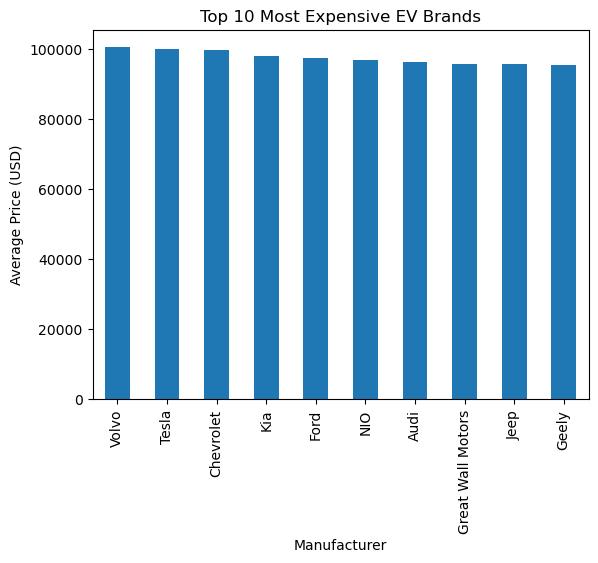

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show top 10 most expensive manufacturers
avg_price = data.groupby('Manufacturer')['Price_USD'].mean().sort_values(ascending=False).head(10)
avg_price.plot(kind='bar', title='Top 10 Most Expensive EV Brands')
plt.ylabel('Average Price (USD)')
plt.show()

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- CELL 1: SETUP & DATA LOADING ---
# Creating a dummy dataset (Replace this with: data = pd.read_csv('your_file.csv'))
data = pd.DataFrame({
    'Manufacturer': ['Tesla', 'Tesla', 'Ford', 'Ford', 'BYD', 'BYD'],
    'Model': ['Model 3', 'Model Y', 'Mach-E', 'F-150', 'Atto 3', 'Han'],
    'Battery_Type': ['Lithium-ion', 'LFP', 'Lithium-ion', 'LFP', 'LFP', 'Lithium-ion'],
    'Charging_Type': ['NACS', 'NACS', 'CCS', 'CCS', 'CCS', 'Type 2'],
    'Color': ['Red', 'Blue', 'Black', 'White', 'Grey', 'Red'],
    'Price_USD': [45000, 52000, 48000, 65000, 38000, 42000]
})

# Clean column names (removes hidden spaces)
data.columns = data.columns.str.strip()
print("Original Data Head:")
display(data.head())

# --- CELL 2: ENCODING PIPELINE ---

# 1. One-Hot Encoding (Battery & Charging)
# We use 'if' checks so you can run this cell multiple times without KeyErrors
if 'Battery_Type' in data.columns:
    data = pd.get_dummies(data, columns=['Battery_Type'], prefix='Battery')

if 'Charging_Type' in data.columns:
    data = pd.get_dummies(data, columns=['Charging_Type'], prefix='Charge')

# 2. Label Encoding (Color)
if 'Color' in data.columns:
    le = LabelEncoder()
    data['Color_Encoded'] = le.fit_transform(data['Color'])

# 3. Target Encoding (Manufacturer & Model)
# Replaces names with the average Price_USD for that group
if 'Price_USD' in data.columns:
    if 'Manufacturer' in data.columns:
        data['Manufacturer_Encoded'] = data.groupby('Manufacturer')['Price_USD'].transform('mean')
    
    if 'Model' in data.columns:
        data['Model_Encoded'] = data.groupby('Model')['Price_USD'].transform('mean')

# --- CELL 3: FINAL CLEANUP & RESULTS ---

# Optional: Drop the original categorical columns if you're ready for Machine Learning
cols_to_drop = ['Manufacturer', 'Model', 'Color']
data_final = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

print("\nProcessing Complete!")
print(f"Final Shape: {data_final.shape}")
display(data_final.head())

# Quick check on the new columns
print("\nNew Columns Created:")
for col in data_final.columns:
    print(f"- {col}")


Original Data Head:


,Manufacturer,Model,Battery_Type,Charging_Type,Color,Price_USD
0,Tesla,Model 3,Lithium-ion,NACS,Red,45000
1,Tesla,Model Y,LFP,NACS,Blue,52000
2,Ford,Mach-E,Lithium-ion,CCS,Black,48000
3,Ford,F-150,LFP,CCS,White,65000
4,BYD,Atto 3,LFP,CCS,Grey,38000



Processing Complete!
Final Shape: (6, 9)


,Price_USD,Battery_LFP,Battery_Lithium-ion,Charge_CCS,Charge_NACS,Charge_Type 2,Color_Encoded,Manufacturer_Encoded,Model_Encoded
0,45000,False,True,False,True,False,3,48500.0,45000.0
1,52000,True,False,False,True,False,1,48500.0,52000.0
2,48000,False,True,True,False,False,0,56500.0,48000.0
3,65000,True,False,True,False,False,4,56500.0,65000.0
4,38000,True,False,True,False,False,2,40000.0,38000.0



New Columns Created:
- Price_USD
- Battery_LFP
- Battery_Lithium-ion
- Charge_CCS
- Charge_NACS
- Charge_Type 2
- Color_Encoded
- Manufacturer_Encoded
- Model_Encoded
